# Taylor–Couette flow: curved no-slip walls

Fluid between an inner cylinder (radius $r_1$, rotating at $\Omega$) and a fixed outer cylinder ($r_2$), at low Reynolds number. The azimuthal velocity and the torque on the inner cylinder are known exactly:

$$u_\theta(r) = A r + \frac{B}{r},\quad A=-\frac{\Omega r_1^2}{r_2^2-r_1^2},\ B=\frac{\Omega r_1^2 r_2^2}{r_2^2-r_1^2},\qquad T = -4\pi\rho\nu B\ \text{(torque of the fluid on the inner cylinder, per unit depth)}.$$

The inner wall is convex (fluid outside), the outer concave (fluid inside), and the inner wall moves: this tests the curved no-slip closure, the wall-velocity law $u_w=\Omega\times r$ and the torque booking.
Both walls are exact analytic walls (`DiskArrayRep` and an `ImplicitRep` disk with the solid outside).

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries.scene.implicitBodies import DiskBody
from warpSPHBoundaries.scene.scene import Body, DiskArrayRep, ImplicitRep, Scene
from warpSPHBoundaries.sim.references import couette_cylinders
from warpSPHBoundaries.sim.solvers import make_solver, wall_gap

n = {"quick": 48, "full": 64}[QUALITY]
T = {"quick": 8.0, "full": 20.0}[QUALITY]
r1, r2, omega, nu = 0.2, 0.5, 1.0, 0.0185
dx = 1.0 / n
print(f"scheme {SCHEME}, n = {n}, Re = Omega r1 (r2-r1)/nu = {omega * r1 * (r2 - r1) / nu:.2f}")

scheme delta, n = 48, Re = Omega r1 (r2-r1)/nu = 3.24


## Set-up
The lattice is cut at the wall gap of the scheme's calibration from both walls (a square lattice, no wall-fitted rings).

In [3]:
g = wall_gap(SCHEME, dx)
m = int(r2 / dx) + 2
X, Y = np.meshgrid(dx * (np.arange(-m, m + 1) + 0.5), dx * (np.arange(-m, m + 1) + 0.5), indexing="ij")
P = np.stack([X.ravel(), Y.ravel()], 1)
rr = np.linalg.norm(P, axis=1)
pos = P[(rr >= r1 + g - 0.01 * dx) & (rr <= r2 - g + 0.01 * dx)]
inner = Body(bodyId=0, center=(0.0, 0.0), angularVelocity=omega, reps=[DiskArrayRep([(0.0, 0.0)], [r1])])
outer = Body(bodyId=1, center=(0.0, 0.0), reps=[ImplicitRep(DiskBody(center=(0.0, 0.0), radius=r2, solid="outside"))])
extra = {"maxDt": 5e-3} if SCHEME == "dfsph" else {}
sol = make_solver(SCHEME, pos, dx, Scene([inner, outer], DEVICE), nu=nu, c0=10 * omega * r1, device=DEVICE, **extra)
_, A, B, Tex = couette_cylinders(1.0, r1, r2, omega, nu)
print(f"N = {sol.n};  exact torque on the inner cylinder {Tex:+.5f}")

torque_in, torque_out = [], []
def record(s):
    inner.angle = 0.0                                # an axisymmetric disk: keep its pose fixed, only its wall velocity matters
    torque_in.append((s.time, s.torque(0))); torque_out.append(s.torque(1))

N = 1432;  exact torque on the inner cylinder -0.01107


## Integration

In [4]:
sol.run(T, every=T / 4, callback=record, report=lambda s: f"torque on the inner cylinder {torque_in[-1][1]:+.5f}")

  t    2.003  dt 6.59e-03  vmax    0.186  torque on the inner cylinder -0.01089  [28 s]


  t    4.006  dt 6.59e-03  vmax    0.186  torque on the inner cylinder -0.01078  [52 s]


  t    6.002  dt 6.59e-03  vmax    0.185  torque on the inner cylinder -0.01079  [70 s]


  t    8.005  dt 6.59e-03  vmax    0.185  torque on the inner cylinder -0.01079  [87 s]


True

## Profile and torque against the exact solution

profile amplitude / exact = 0.9986
torque on the inner cylinder -0.01078  exact -0.01107  ratio 0.9739
torque on the outer cylinder / (-inner) = 0.8888   (equal and opposite in steady state)


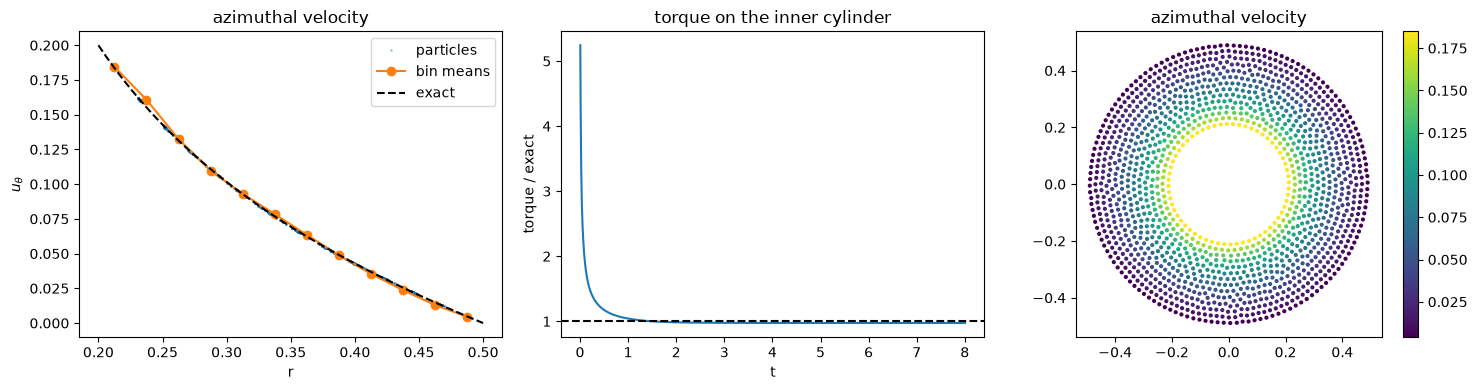

In [5]:
x, v = sol.x, sol.v
r = np.linalg.norm(x, axis=1)
ut = (x[:, 0] * v[:, 1] - x[:, 1] * v[:, 0]) / r
ex, _, _, _ = couette_cylinders(r, r1, r2, omega)
amp = float((ut * ex).sum() / (ex * ex).sum())
t_arr, T1 = map(np.array, zip(*torque_in))
T1m = T1[-200:].mean()
print(f"profile amplitude / exact = {amp:.4f}")
print(f"torque on the inner cylinder {T1m:+.5f}  exact {Tex:+.5f}  ratio {T1m / Tex:.4f}")
if SCHEME == "delta":
    print(f"torque on the outer cylinder / (-inner) = {np.mean(torque_out[-200:]) / -T1m:.4f}   (equal and opposite in steady state)")

bins = np.linspace(r1, r2, 13)
rc = 0.5 * (bins[1:] + bins[:-1])
prof = [ut[(r >= a) & (r < b)].mean() for a, b in zip(bins[:-1], bins[1:])]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(r, ut, ".", ms=2, alpha=0.3, label="particles"); ax[0].plot(rc, prof, "o-", label="bin means")
rr_ = np.linspace(r1, r2, 100); ax[0].plot(rr_, couette_cylinders(rr_, r1, r2, omega)[0], "k--", label="exact"); ax[0].set(xlabel="r", ylabel=r"$u_\theta$", title="azimuthal velocity"); ax[0].legend()
ax[1].plot(t_arr, T1 / Tex); ax[1].axhline(1, color="k", ls="--"); ax[1].set(xlabel="t", ylabel="torque / exact", title="torque on the inner cylinder")
q = ax[2].scatter(x[:, 0], x[:, 1], c=ut, s=4); ax[2].set(aspect="equal", title="azimuthal velocity"); plt.colorbar(q, ax=ax[2])
plt.tight_layout(); plt.show()

## What to look at

* the profile amplitude and the torque ratio test the same closure from two sides (the field and the integrated wall traction); they should agree within a few per cent and approach 1 with resolution;
* `dfsph` is reproducible at n = 48 (and fragile at n = 32: the run-to-run scatter and an occasional CUDA assert at the impulsive start of the rotation are an open item of the moving-wall DFSPH path); its torque is within 4 % but the profile amplitude comes out about 0.83 — the same value as `scripts/studies/dfsph_viscous.py couette --n 48`, not yet understood;
* for `delta` the torque on the outer cylinder balances the inner one; `dfsph` books the viscous torque of the inner body only, whose pressure acts through its centre.